# Pairs Trading on the S&P 500: a Statistical-Arbitrage Backtest

**Financial Markets Analytics — Final Project (Variant A), A.Y. 2025/2026**
*Prof. G. Forte*

---

**Research question.** Can a market-neutral statistical-arbitrage strategy based on
*pairs trading* deliver risk-adjusted returns superior to a simple buy-and-hold of the
underlying equity universe (the S&P 500)?

**Approach in one paragraph.** Following Gatev, Goetzmann & Rouwenhorst (2006) and the
cointegration approach of Vidyamurthy (2004), we repeatedly (i) *form* pairs by scanning
all same-sector combinations of S&P 500 members for cointegration over a 3-year window
(Engle–Granger test), (ii) *trade* the best 20 pairs out-of-sample for the following
6 months with z-score entry/exit/stop rules on the spread, and (iii) roll the whole
procedure forward from 1993 to 2018. The resulting weekly equity curve — net of
transaction costs — is compared with the S&P 500 index on return, volatility, Sharpe
ratio and drawdown.

## 1. Methodology overview and design choices

The strategy follows the classic two-phase scheme:

| Phase | What happens | Our choice |
|---|---|---|
| **Formation** | identify candidate pairs | 3 years (156 weeks) of weekly prices |
| **Trading** | trade the selected pairs out-of-sample | next 6 months (26 weeks), then roll |

Design choices required by the assignment:

| Parameter | Choice | Rationale |
|---|---|---|
| Formation window | 156 weeks (3y) | enough observations for cointegration tests; standard in the literature |
| Selection criterion | Engle–Granger cointegration test on log-prices | statistically grounded; identifies genuine long-run equilibria (course, Sec. 3) |
| Sector restriction | **same sector only** | economic rationale behind the statistical link; reduces spurious pairs and the multiple-testing problem |
| Pairs held | top 20 by p-value, each stock in at most one pair | diversification without dilution; avoids concentration in one name |
| Capital allocation | equal weight (1/20 per pair) | simple, transparent; robustness beats optimization out-of-sample |
| Z-score parameters | estimated on the formation window and **kept fixed** during trading | no look-ahead; the trading period is genuinely out-of-sample |
| Entry / exit / stop | \|z\| > 2.0 / \|z\| < 0.5 / \|z\| > 3.0 | course convention; stop guards against cointegration breakdown |
| Max holding period | force-close at the end of the 26-week trading window | positions never outlive the relationship estimate |
| Rebalancing frequency | **weekly** (Friday close) | assignment requires weekly or monthly, not daily |
| Transaction costs | 10 bps of traded notional per position change (~20 bps round trip) | realistic for liquid US large caps incl. slippage |

Additional quality filters at formation (motivated in §3): OLS hedge ratio
$\beta \in [0.1, 10]$, spread half-life between 1 and 26 weeks, Engle–Granger
$p < 0.05$.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

ROOT = Path.cwd()
if ROOT.name == "legacy":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent
CACHE = ROOT / "data" / "cache"
ANN = 52  # weekly annualization factor

# strategy parameters (see table above)
P = dict(
    form_weeks=156, trade_weeks=26,
    n_pairs=20, p_max=0.05,
    entry=2.0, exit=0.5, stop=3.0,
    fee=0.0010,                    # per unit of turnover
    min_price=5.0, max_weekly_ret=0.50,
    beta_min=0.1, beta_max=10.0,
    hl_min=1.0, hl_max=26.0,
)

## 2. Data

The dataset is the survivorship-bias-free S&P 500 workbook provided with the assignment
(`SPX500 Original.xlsm`): Bloomberg prices of **1,355 securities** that were members of
the index at some point between **December 1990 and November 2018**, together with
monthly index weights, a sector classification and the S&P 500 index level itself.

Because the workbook is a 123 MB macro-enabled file, a one-off script
(**`python -m pairs_trading.extract`**) streams the sheet XML and caches
the relevant sheets in Parquet format:

| Cache file | Source sheet | Content |
|---|---|---|
| `spx_prices_daily.parquet` | *Price daily* | daily close, 7,544 × 1,355 |
| `spx_prices_weekly.parquet` | *Price daily*, resampled | **Friday close, 1,509 × 1,355 — used by the strategy** |
| `spx_weights_monthly.parquet` | *Peso* | monthly index weights → membership mask |
| `spx_sectors.csv` | sector sheets | Bloomberg sector of each ticker |
| `spx_index_weekly.parquet` | *AC* | S&P 500 index level (benchmark) |
| `spx_names.csv` | *Price* | company names |

### 2.1 Data-cleaning steps (documented as required)

1. **Excel serial dates** converted to timestamps (origin 1899-12-30).
2. **Sector map — a real data-inspection catch.** The *Sector* sheet contains only
   unevaluated Bloomberg formulas (`#NAME?`), so the map must be rebuilt from the ten
   per-sector 0/1 sheets. There we found that the **header row is misaligned by one
   column relative to the data** (an off-by-one in the workbook construction: read at
   face value, ExxonMobil would be "Consumer, Cyclical" and JPMorgan "Industrial").
   Data column $c$ actually belongs to the $c$-th ticker of the master list. We verified
   the corrected alignment on a panel of 30 well-known companies: **30/30 correct**
   (vs ~6/30 with the nominal alignment). The very first ticker (3M) loses its data
   column to the same off-by-one and was assigned to Industrial manually. 1,355 of
   1,355 tickers classified.
3. **Membership without survivorship bias**: a stock enters the tradable universe only in
   months where its index weight is positive — exactly the periods in which it actually
   belonged to the S&P 500. Stocks that later left the index (delistings, M&A) are
   therefore *included* while they were members: no survivorship bias.
4. **Weekly resampling** (last available close of each week, Friday-anchored) — the
   assignment asks for weekly or monthly frequency, avoiding daily.
5. **Isolated missing prices** inside a trading window are forward-filled; a pair is
   force-closed at the last date on which both legs quote (handles mid-window delistings).
6. **Quality filters at formation** (§3): complete 3-year history, price ≥ \$5, no weekly
   move above 50 % — removes penny stocks and data glitches (e.g. unadjusted corporate
   actions) from the candidate set, they would produce spurious "cointegration".

In [2]:
prices = pd.read_parquet(f"{CACHE}/spx_prices_weekly.parquet")
weights = pd.read_parquet(f"{CACHE}/spx_weights_monthly.parquet")
sectors = pd.read_csv(f"{CACHE}/spx_sectors.csv", index_col=0)["sector"]
names = pd.read_csv(f"{CACHE}/spx_names.csv", index_col=0)["name"]
spx = pd.read_parquet(f"{CACHE}/spx_index_weekly.parquet")["SPX"]

log_prices = np.log(prices)
dates = prices.index
membership = weights.fillna(0) > 0

print(f"Weekly prices:  {prices.shape[0]} weeks x {prices.shape[1]} tickers "
      f"({dates[0].date()} -> {dates[-1].date()})")
print(f"Members per month: {membership.sum(axis=1).min()}–{membership.sum(axis=1).max()}")
print(f"Sector classified: {sectors.notna().sum()} tickers, "
      f"{sectors.nunique()} sectors")

Weekly prices:  1509 weeks x 1355 tickers (1990-01-05 -> 2018-11-30)
Members per month: 498–506
Sector classified: 1355 tickers, 10 sectors


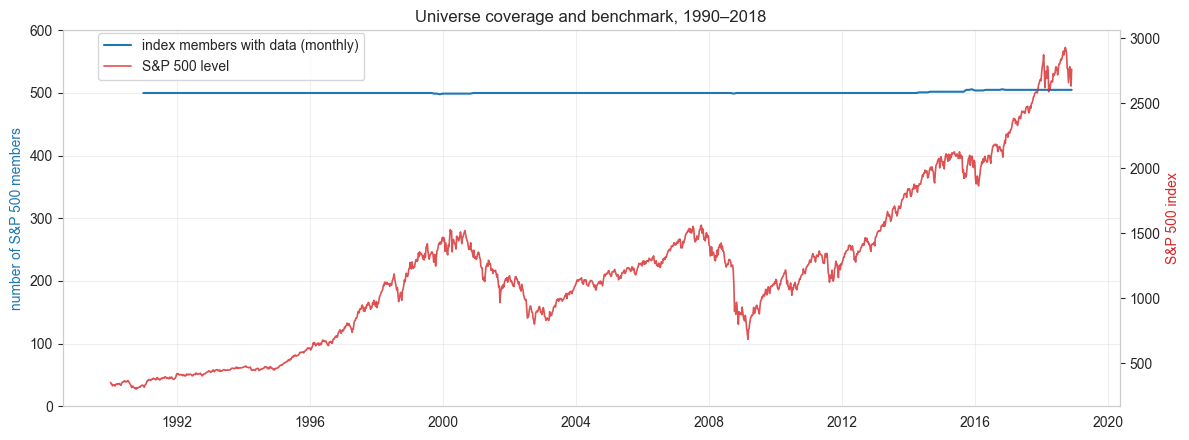

Tickers with at least one weekly price: 1355
Average time in the index: 10.3 years per ticker (price history often extends outside membership; only membership periods are traded)


In [3]:
# Universe coverage over time: the dataset really is free of survivorship bias
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(membership.index, membership.sum(axis=1), color="#1f77b4", lw=1.5,
         label="index members with data (monthly)")
ax1.set_ylabel("number of S&P 500 members", color="#1f77b4")
ax1.set_ylim(0, 600)
ax2 = ax1.twinx()
ax2.plot(spx.index, spx, color="#d62728", lw=1.2, alpha=0.8, label="S&P 500 level")
ax2.set_ylabel("S&P 500 index", color="#d62728")
ax2.grid(False)
ax1.set_title("Universe coverage and benchmark, 1990–2018")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.93))
plt.tight_layout()
plt.show()

ever = prices.notna().any()
print(f"Tickers with at least one weekly price: {ever.sum()}")
print(f"Average time in the index: {membership.sum().mean()/12:.1f} years per ticker "
      f"(price history often extends outside membership; only membership periods "
      f"are traded)")

## 3. Formation machinery

### 3.1 Eligible universe at each formation date

At every formation date we keep only stocks that (i) are **current index members**
(positive weight in the latest monthly snapshot — this is what makes the backtest
survivorship-bias-free), (ii) have a **complete weekly price history** over the 156-week
formation window, (iii) trade above **\$5**, and (iv) show no weekly move above **50 %**.

Formation 2004-01-09 -> 2006-12-29: 475 eligible stocks


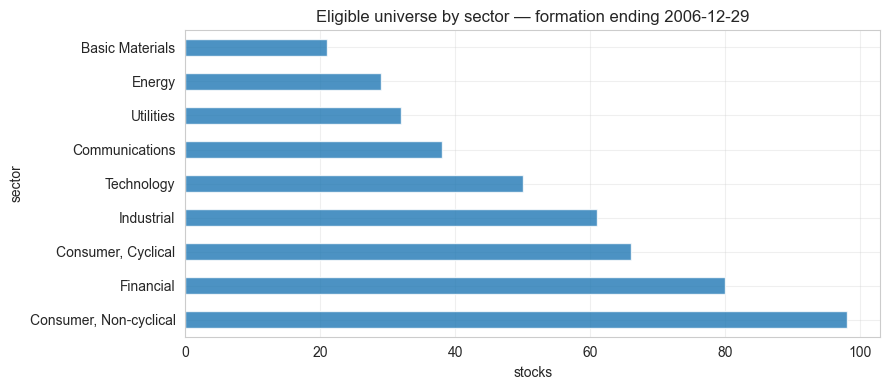

In [4]:
def members_at(date):
    """Index members according to the most recent monthly weight snapshot."""
    snap = weights.index[weights.index <= date]
    if len(snap) == 0:
        return pd.Index([])
    w = weights.loc[snap[-1]]
    return w.index[w.fillna(0) > 0]


def eligible(f0, f1):
    """Tickers usable for the formation window dates[f0:f1]."""
    px = prices.iloc[f0:f1]
    ok = px.notna().all()                                   # complete history
    ok &= px.min() >= P["min_price"]                        # no penny stocks
    ok &= px.pct_change().abs().max() <= P["max_weekly_ret"]  # no glitches
    ok &= ok.index.isin(members_at(dates[f1 - 1]))          # in the index now
    ok &= ok.index.isin(sectors.index)                      # sector known
    return ok.index[ok]


# example: the formation window ending in December 2006
ex_end = dates.get_loc(dates[dates <= "2006-12-29"][-1]) + 1
ex_start = ex_end - P["form_weeks"]
elig = eligible(ex_start, ex_end)
print(f"Formation {dates[ex_start].date()} -> {dates[ex_end-1].date()}: "
      f"{len(elig)} eligible stocks")
sectors.loc[elig].value_counts().plot(kind="barh", figsize=(9, 4),
                                      color="#1f77b4", alpha=0.8)
plt.title(f"Eligible universe by sector — formation ending {dates[ex_end-1].date()}")
plt.xlabel("stocks")
plt.tight_layout()
plt.show()

### 3.2 Pair selection: Engle–Granger scan within sectors

For every same-sector pair $(y, x)$ we run the **Engle–Granger two-step test** on weekly
log-prices over the formation window (`statsmodels.tsa.stattools.coint`, which regresses
$y_t = \alpha + \beta x_t + \varepsilon_t$ and applies an ADF test with the appropriate
cointegration critical values to $\hat\varepsilon_t$). The test is asymmetric in $(y,x)$,
so we run both orderings and keep the better one.

A pair survives only if:

* Engle–Granger $p < 0.05$ (spread stationary at the 5 % level);
* hedge ratio $\beta \in [0.1, 10]$ (economically sensible, positive co-movement);
* spread **half-life** between 1 and 26 weeks — from the AR(1) fit
  $\Delta s_t = \phi\,(s_{t-1}-\mu) + \nu_t$, $T_{1/2} = \ln 2 / (-\phi)$: the spread must
  revert fast enough to be tradable within a 26-week window, but not so fast that it is
  just noise;
* survivors are ranked by p-value and picked greedily so that **each stock appears in at
  most one pair**, until 20 pairs are selected.

Working with **log-prices** makes the spread scale-free: positions become dollar
proportions and the spread change is directly a long-short return.

In [5]:
def half_life(spread):
    """Half-life (weeks) of mean reversion from the AR(1) fit of the spread."""
    ds = np.diff(spread)
    lag = spread[:-1] - spread.mean()
    phi = np.dot(lag, ds) / np.dot(lag, lag)
    return np.log(2) / -phi if phi < 0 else np.inf


def scan_pairs(f0, f1):
    """Engle-Granger scan of all same-sector pairs on dates[f0:f1].

    Returns the top pairs with their formation-window parameters
    (alpha, beta, spread mean/std, half-life)."""
    tickers = eligible(f0, f1)
    lp = log_prices.iloc[f0:f1][tickers]
    rows = []
    for sec_name, group in sectors.loc[tickers].groupby(sectors):
        tk = list(group.index)
        arr = lp[tk].values
        for i in range(len(tk)):
            for j in range(i + 1, len(tk)):
                a1, a2 = arr[:, i], arr[:, j]
                _, p1, _ = coint(a1, a2, trend="c", maxlag=1, autolag=None)
                _, p2, _ = coint(a2, a1, trend="c", maxlag=1, autolag=None)
                y, x, p = (a1, a2, p1) if p1 <= p2 else (a2, a1, p2)
                yn, xn = (tk[i], tk[j]) if p1 <= p2 else (tk[j], tk[i])
                if p > P["p_max"]:
                    continue
                alpha, beta = np.linalg.lstsq(sm.add_constant(x), y, rcond=None)[0]
                if not (P["beta_min"] <= beta <= P["beta_max"]):
                    continue
                spread = y - (alpha + beta * x)
                hl = half_life(spread)
                if not (P["hl_min"] <= hl <= P["hl_max"]):
                    continue
                rows.append(dict(y=yn, x=xn, sector=sec_name, pval=p,
                                 alpha=alpha, beta=beta,
                                 mu=spread.mean(), sigma=spread.std(),
                                 half_life=hl))
    if not rows:
        return pd.DataFrame()
    ranked = pd.DataFrame(rows).sort_values("pval")
    used, keep = set(), []
    for _, r in ranked.iterrows():
        if r["y"] in used or r["x"] in used:
            continue
        keep.append(r)
        used.update([r["y"], r["x"]])
        if len(keep) >= P["n_pairs"]:
            break
    return pd.DataFrame(keep).reset_index(drop=True)

## 4. One formation window under the microscope

Before running the full simulation, we illustrate the machinery on a single window:
formation over **2004–2006**, trading in the **first half of 2007**.

In [6]:
ex_pairs = scan_pairs(ex_start, ex_end)
show = ex_pairs.copy()
show["pair"] = (show["y"].str.replace(" UN Equity", "", regex=False) + "  /  "
                + show["x"].str.replace(" UN Equity", "", regex=False))
show["names"] = (names.reindex(show["y"]).reset_index(drop=True) + "  /  "
                 + names.reindex(show["x"]).reset_index(drop=True))
cols = ["pair", "names", "sector", "pval", "beta", "half_life"]
show[cols].round({"pval": 4, "beta": 2, "half_life": 1}).head(20)

,pair,names,sector,pval,beta,half_life
0,SNV / ALL,Synovus Financial Corp / Allstate Corp/The,Financial,0.0000,0.51,2.3
1,LNC / MEL,Lincoln National Corp / Mellon Financial Corp,Financial,0.0000,0.95,3.9
2,TMK / WFC,Torchmark Corp / Wells Fargo & Co,Financial,0.0000,0.89,3.0
3,SWK / LLL,Stanley Black & Decker Inc / L3 Technologies...,Industrial,0.0000,0.55,2.4
4,COST UW Equity / SBUX UW Equity,Costco Wholesale Corp / Starbucks Corp,"Consumer, Cyclical",0.0000,0.52,2.0
5,NOV / CHK,National Oilwell Varco Inc / Chesapeake Ener...,Energy,0.0001,0.96,2.8
6,MWV / MAS,WestRock MWV LLC / Masco Corp,Industrial,0.0001,0.62,3.1
7,CMX / WYE,Caremark Rx Inc / Wyeth LLC,"Consumer, Non-cyclical",0.0002,1.72,4.0
8,SII / BHI,Smith International Inc / Baker Hughes a GE ...,Energy,0.0002,0.64,3.3
9,EMR / TEX,Emerson Electric Co / Terex Corp,Industrial,0.0002,0.30,3.2


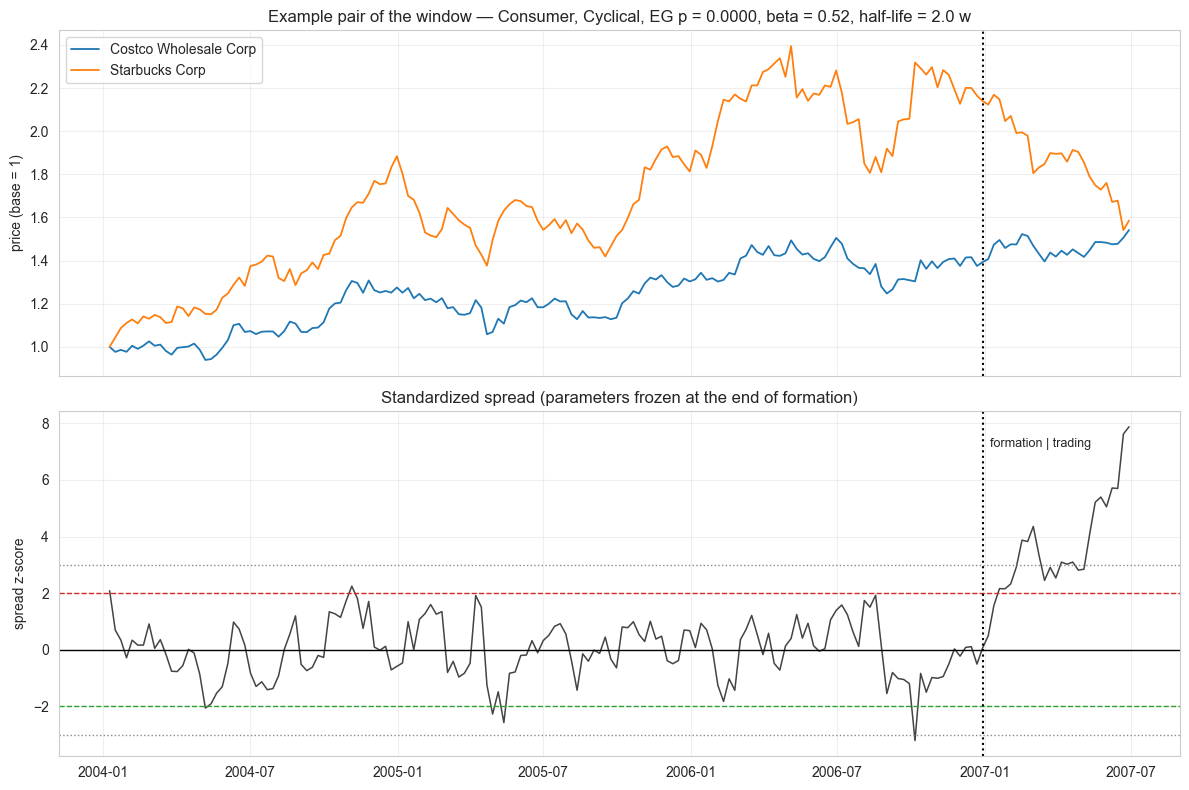

In [7]:
# Detailed look at one pair of this window. Among the selected pairs we show
# one that actually generates entry signals out-of-sample (many of the best
# pairs simply stay inside the +/-2 sigma band for the whole 26 weeks).
t_end = min(ex_end + P["trade_weeks"], len(dates))


def n_entry_signals(p):
    ly = log_prices[p["y"]].iloc[ex_end:t_end]
    lx = log_prices[p["x"]].iloc[ex_end:t_end]
    z_ = (ly - (p["alpha"] + p["beta"] * lx) - p["mu"]) / p["sigma"]
    return int((z_.abs() >= P["entry"]).sum())


sig_count = ex_pairs.apply(n_entry_signals, axis=1)
bp = ex_pairs.loc[sig_count.idxmax()]
win = slice(ex_start, t_end)
py, px = prices[bp["y"]].iloc[win], prices[bp["x"]].iloc[win]
ly, lx = log_prices[bp["y"]].iloc[win], log_prices[bp["x"]].iloc[win]
z_all = (ly - (bp["alpha"] + bp["beta"] * lx) - bp["mu"]) / bp["sigma"]
split_date = dates[ex_end - 1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(py / py.iloc[0], lw=1.3, label=names.get(bp["y"], bp["y"]))
axes[0].plot(px / px.iloc[0], lw=1.3, label=names.get(bp["x"], bp["x"]))
axes[0].axvline(split_date, color="k", ls=":", lw=1.5)
axes[0].set_ylabel("price (base = 1)")
axes[0].set_title(f"Example pair of the window — {bp['sector']}, "
                  f"EG p = {bp['pval']:.4f}, beta = {bp['beta']:.2f}, "
                  f"half-life = {bp['half_life']:.1f} w")
axes[0].legend()

axes[1].plot(z_all, color="#444", lw=1.1)
for lvl, c, ls in [(0, "k", "-"), (P["entry"], "#d62728", "--"),
                   (-P["entry"], "#2ca02c", "--"), (P["stop"], "#888", ":"),
                   (-P["stop"], "#888", ":")]:
    axes[1].axhline(lvl, color=c, ls=ls, lw=1)
axes[1].axvline(split_date, color="k", ls=":", lw=1.5)
axes[1].text(split_date, axes[1].get_ylim()[1]*0.85, "  formation | trading",
             fontsize=9)
axes[1].set_ylabel("spread z-score")
axes[1].set_title("Standardized spread (parameters frozen at the end of formation)")
plt.tight_layout()
plt.show()

## 5. Trading rules and P&L accounting

**Rules** (weekly, on the frozen z-score):

* **open** long-spread (+1) when $z \le -2$, short-spread (−1) when $z \ge +2$;
* **close** when the z-score reverts inside $\pm 0.5$;
* **stop-loss** when $|z| \ge 3$ — the pair is then locked for the rest of the window
  (a 3-sigma escape is treated as evidence of cointegration breakdown);
* **force-close** at the end of the 26-week window (max holding period), or at the last
  date on which both legs quote if one is delisted mid-window.

**Accounting.** With $\beta > 0$, one unit of capital in a long-spread position is split
$w_y = \frac{1}{1+\beta}$ long in $y$ and $w_x = \frac{\beta}{1+\beta}$ short in $x$
(gross exposure = capital, i.e. Δ-neutral in log-space up to the hedge ratio). The weekly
net return of a pair is

$$ r_t \;=\; \text{pos}_{t-1}\,\big( w_y\,\Delta \log y_t - w_x\,\Delta\log x_t \big)
\;-\; \underbrace{c\;\lvert \Delta \text{pos}_t \rvert}_{\text{transaction costs}} $$

with $c$ = 10 bps per unit of turnover (both legs together trade one unit of gross
notional per unit of position change, so a round trip costs ≈ 20 bps of the capital
committed to the pair). The portfolio return is the equal-weighted average over the
pairs selected in that window; a stopped-out or flat pair simply sits in cash (0 %).

In [8]:
def trade_pair(pair, t0, t1, entry, exit_, stop, fee):
    """Weekly net returns of one pair over the trading rows dates[t0:t1]."""
    ly = log_prices[pair["y"]].iloc[t0 - 1:t1]
    lx = log_prices[pair["x"]].iloc[t0 - 1:t1]
    valid = ly.notna() & lx.notna()
    if valid.sum() < 3:
        return pd.Series(0.0, index=dates[t0:t1])
    last = valid[::-1].idxmax()          # last date with both legs quoted
    ly, lx = ly.ffill(), lx.ffill()
    z = (ly - (pair["alpha"] + pair["beta"] * lx) - pair["mu"]) / pair["sigma"]
    b = pair["beta"]
    wy, wx = 1 / (1 + b), b / (1 + b)
    pos = np.zeros(len(z))
    p, stopped = 0, False
    for k in range(len(z)):
        zk = z.iloc[k]
        if stopped or z.index[k] > last:
            p = 0
        elif p == 0:
            if zk <= -entry:
                p = +1
            elif zk >= entry:
                p = -1
        elif p == +1 and (zk >= -exit_ or zk <= -stop):
            stopped = zk <= -stop
            p = 0
        elif p == -1 and (zk <= exit_ or zk >= stop):
            stopped = zk >= stop
            p = 0
        pos[k] = p
    pos = pd.Series(pos, index=z.index)
    gross = pos.shift(1) * (wy * ly.diff() - wx * lx.diff())
    costs = fee * pos.diff().abs()
    costs.iloc[-1] += fee * abs(pos.iloc[-1])   # forced close at window end
    net = gross - costs
    return net.fillna(0.0).iloc[1:]      # drop the seed week

Example pair, trading 2007-01-05 -> 2007-06-29: return -3.87%


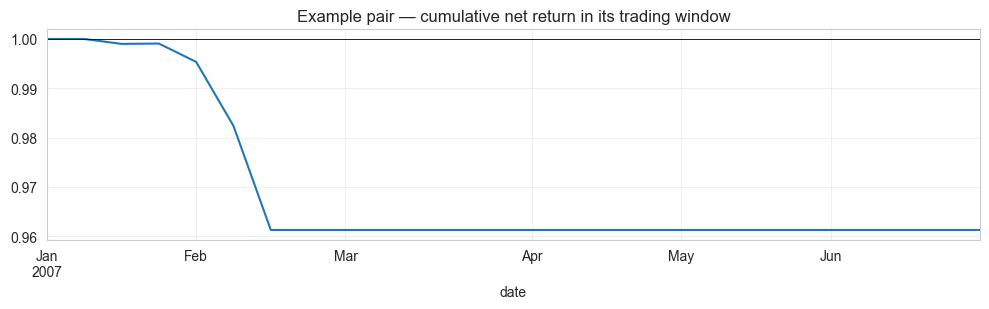

In [9]:
# Sanity check: trade the example pair through H1-2007
r_ex = trade_pair(bp, ex_end, t_end, P["entry"], P["exit"], P["stop"], P["fee"])
eq_ex = (1 + r_ex).cumprod()
print(f"Example pair, trading {dates[ex_end].date()} -> {dates[t_end-1].date()}: "
      f"return {eq_ex.iloc[-1]-1:+.2%}")
eq_ex.plot(figsize=(10, 3.2), color="#1f77b4", lw=1.5,
           title="Example pair — cumulative net return in its trading window")
plt.axhline(1, color="k", lw=0.6)
plt.tight_layout()
plt.show()

## 6. Walk-forward simulation, 1993–2018

The formation + trading scheme is rolled forward in **non-overlapping 26-week steps**:
each window re-selects pairs using only information available at that time, then trades
them out-of-sample. Chaining the 50 trading windows produces a single ~25-year weekly
return series — a genuine out-of-sample track record of the strategy.

In [10]:
%%time
selections = {}          # trading-start index -> pairs DataFrame
for s in range(P["form_weeks"], len(dates) - 1, P["trade_weeks"]):
    selections[s] = scan_pairs(s - P["form_weeks"], s)
print(f"{len(selections)} formation windows scanned")

52 formation windows scanned
CPU times: user 3min 52s, sys: 684 ms, total: 3min 53s
Wall time: 3min 53s


In [11]:
def run_trading(selections, entry, exit_, stop, fee):
    """Chain the out-of-sample trading windows into one weekly return series."""
    out = []
    for s, pairs in selections.items():
        t1 = min(s + P["trade_weeks"], len(dates))
        if len(pairs) == 0:
            out.append(pd.Series(0.0, index=dates[s:t1]))
            continue
        rets = pd.concat([trade_pair(p, s, t1, entry, exit_, stop, fee)
                          for _, p in pairs.iterrows()], axis=1)
        out.append(rets.sum(axis=1) / len(pairs))
    return pd.concat(out)


strat_net = run_trading(selections, P["entry"], P["exit"], P["stop"], P["fee"])
strat_gross = run_trading(selections, P["entry"], P["exit"], P["stop"], 0.0)
print(f"Out-of-sample period: {strat_net.index[0].date()} -> "
      f"{strat_net.index[-1].date()}  ({len(strat_net)} weeks)")

Out-of-sample period: 1993-01-01 -> 2018-11-23  (1352 weeks)


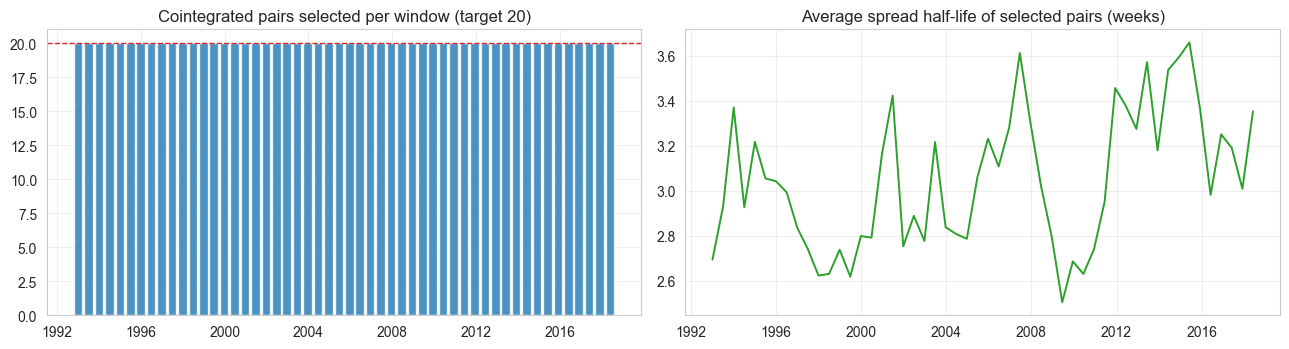

Average pairs per window: 20.0   windows with full 20: 52 / 52


In [12]:
# How many pairs does each window find?
diag = pd.DataFrame(
    [dict(start=dates[s], n=len(p_), hl=p_["half_life"].mean() if len(p_) else np.nan)
     for s, p_ in selections.items()]).set_index("start")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].bar(diag.index, diag["n"], width=150, color="#1f77b4", alpha=0.8)
axes[0].axhline(P["n_pairs"], color="#d62728", ls="--", lw=1)
axes[0].set_title("Cointegrated pairs selected per window (target 20)")
axes[1].plot(diag.index, diag["hl"], color="#2ca02c", lw=1.4)
axes[1].set_title("Average spread half-life of selected pairs (weeks)")
plt.tight_layout()
plt.show()
print(f"Average pairs per window: {diag['n'].mean():.1f}   "
      f"windows with full 20: {(diag['n'] == P['n_pairs']).sum()} / {len(diag)}")

## 7. Performance versus the S&P 500 benchmark

All measures are computed on the same out-of-sample weeks for the strategy (net and
gross of costs) and for the **S&P 500 price index** — the benchmark representing
buy-and-hold of the universe, as required by the assignment.

In [13]:
bench = spx.pct_change().reindex(strat_net.index).fillna(0.0)


def perf_stats(r, benchmark=None):
    eq = (1 + r).cumprod()
    yrs = len(r) / ANN
    dd = eq / eq.cummax() - 1
    downside = r[r < 0].std()
    s = {
        "Total return": eq.iloc[-1] - 1,
        "CAGR": eq.iloc[-1] ** (1 / yrs) - 1,
        "Ann. volatility": np.sqrt(ANN) * r.std(),
        "Sharpe (rf=0)": np.sqrt(ANN) * r.mean() / r.std(),
        "Sortino": np.sqrt(ANN) * r.mean() / downside if downside > 0 else np.nan,
        "Max drawdown": dd.min(),
        "Calmar": (eq.iloc[-1] ** (1 / yrs) - 1) / abs(dd.min()),
        "% positive weeks": (r > 0).mean(),
        "Worst week": r.min(),
    }
    if benchmark is not None:
        s["Corr. with S&P 500"] = r.corr(benchmark)
        s["Beta vs S&P 500"] = r.cov(benchmark) / benchmark.var()
    return pd.Series(s)


order = ["Total return", "CAGR", "Ann. volatility", "Sharpe (rf=0)", "Sortino",
         "Max drawdown", "Calmar", "% positive weeks", "Worst week",
         "Corr. with S&P 500", "Beta vs S&P 500"]
table = pd.DataFrame({
    "Pairs strategy (net)": perf_stats(strat_net, bench),
    "Pairs strategy (gross)": perf_stats(strat_gross, bench),
    "S&P 500 (buy & hold)": perf_stats(bench),
}).reindex(order)
pct = ["Total return", "CAGR", "Ann. volatility", "Max drawdown",
       "% positive weeks", "Worst week"]
fmt = table.astype(object).copy()
fmt.loc[pct] = table.loc[pct].map(lambda v: f"{v:+.2%}" if pd.notna(v) else "—")
other = [i for i in fmt.index if i not in pct]
fmt.loc[other] = table.loc[other].map(
    lambda v: f"{v:.2f}" if pd.notna(v) else "—")
fmt

,Pairs strategy (net),Pairs strategy (gross),S&P 500 (buy & hold)
Total return,-7.23%,+1.43%,+498.62%
CAGR,-0.29%,+0.05%,+7.12%
Ann. volatility,+1.53%,+1.52%,+16.41%
Sharpe (rf=0),-0.18,0.04,0.50
Sortino,-0.23,0.05,0.65
Max drawdown,-13.55%,-10.09%,-56.24%
Calmar,-0.02,0.01,0.13
% positive weeks,+45.64%,+47.41%,+56.58%
Worst week,-1.79%,-1.77%,-18.20%
Corr. with S&P 500,0.09,0.09,—


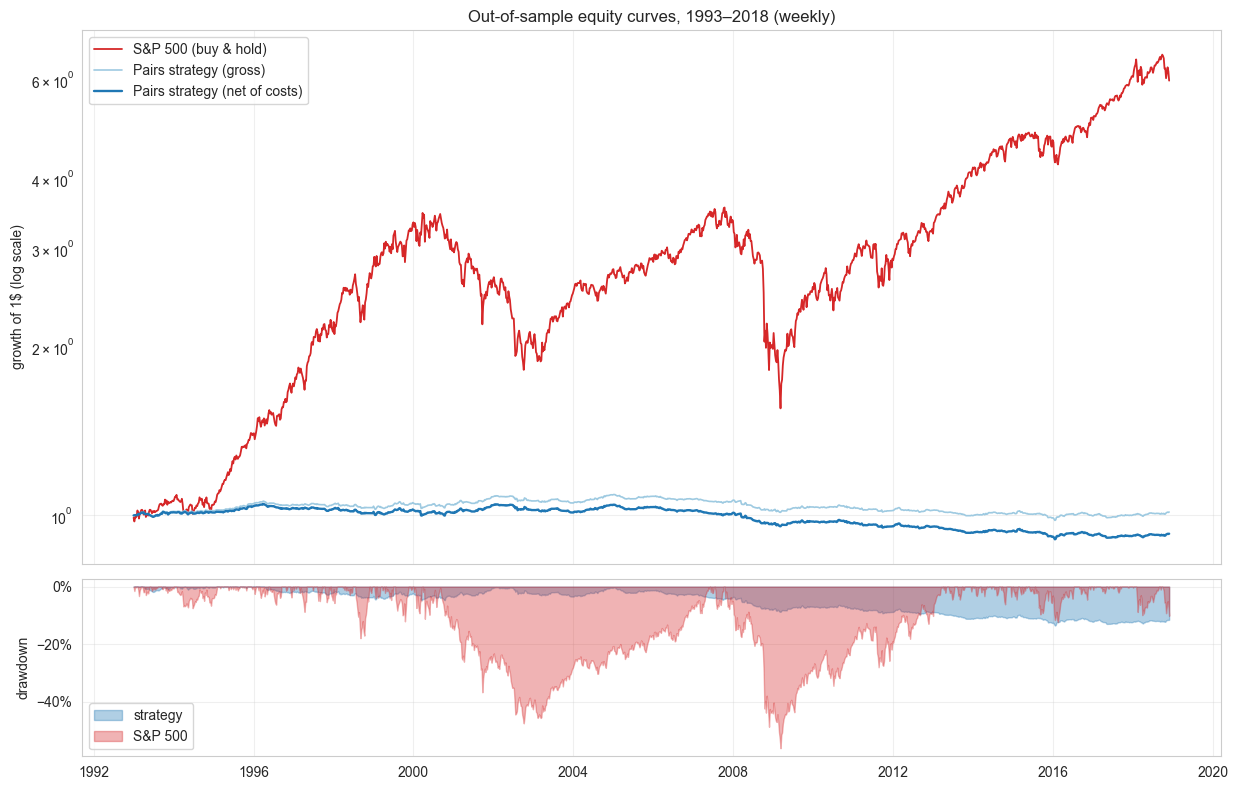

In [14]:
# Equity curves and drawdowns
eq_net = (1 + strat_net).cumprod()
eq_gross = (1 + strat_gross).cumprod()
eq_spx = (1 + bench).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(eq_spx, color="#d62728", lw=1.3, label="S&P 500 (buy & hold)")
axes[0].plot(eq_gross, color="#9ecae1", lw=1.2, label="Pairs strategy (gross)")
axes[0].plot(eq_net, color="#1f77b4", lw=1.7, label="Pairs strategy (net of costs)")
axes[0].set_yscale("log")
axes[0].set_ylabel("growth of 1$ (log scale)")
axes[0].set_title("Out-of-sample equity curves, 1993–2018 (weekly)")
axes[0].legend(loc="upper left")

for r_, c_, l_ in [(strat_net, "#1f77b4", "strategy"), (bench, "#d62728", "S&P 500")]:
    e = (1 + r_).cumprod()
    axes[1].fill_between(e.index, (e / e.cummax() - 1) * 100, 0,
                         color=c_, alpha=0.35, label=l_)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylabel("drawdown")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

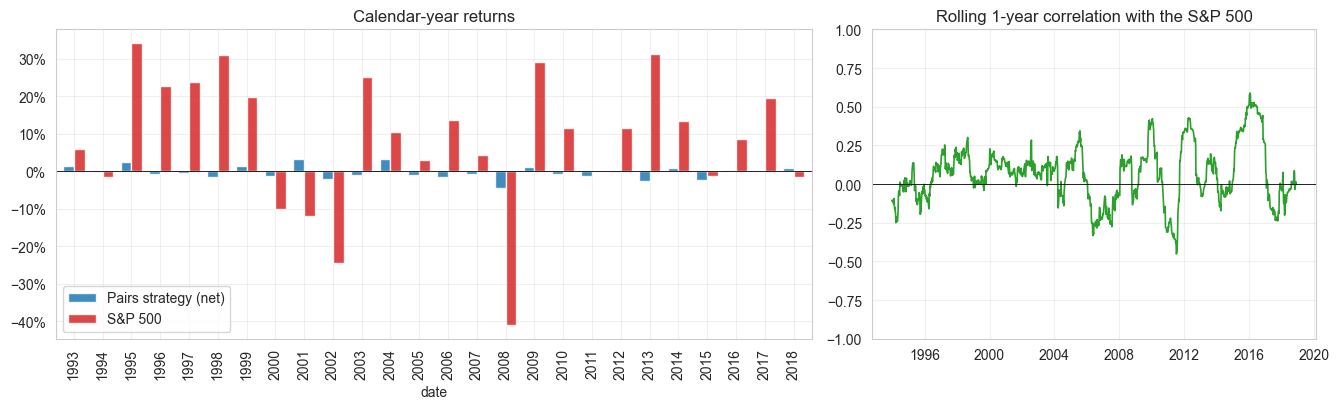

Years with positive strategy return: 9 / 26
Strategy return in 2008: -4.6%  (S&P 500: -41.0%)


In [15]:
# Calendar-year returns and market neutrality
ann_strat = (1 + strat_net).groupby(strat_net.index.year).prod() - 1
ann_spx = (1 + bench).groupby(bench.index.year).prod() - 1
yrs_df = pd.DataFrame({"Pairs strategy (net)": ann_strat, "S&P 500": ann_spx})

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2),
                         gridspec_kw={"width_ratios": [1.7, 1]})
yrs_df.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#d62728"], alpha=0.85,
            width=0.75)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Calendar-year returns")
axes[0].axhline(0, color="k", lw=0.6)

roll_corr = strat_net.rolling(52).corr(bench)
axes[1].plot(roll_corr, color="#2ca02c", lw=1.2)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_ylim(-1, 1)
axes[1].set_title("Rolling 1-year correlation with the S&P 500")
plt.tight_layout()
plt.show()
print(f"Years with positive strategy return: {(ann_strat > 0).sum()} / {len(ann_strat)}")
print(f"Strategy return in 2008: {ann_strat.get(2008, np.nan):+.1%}  "
      f"(S&P 500: {ann_spx.get(2008, np.nan):+.1%})")

### 7.1 Subperiod analysis

Gatev et al. (2006) documented that pairs-trading profits were already shrinking through
the 1990s, and Do & Faff (2010) showed the decline continued afterwards as markets became
more efficient and more arbitrage capital chased the same signal. To see where our
implementation earns (or loses) its money, we split the 26-year track record into two
halves and recompute all measures.

In [16]:
periods = {"1993–2002": strat_net.index < "2003-01-01",
           "2003–2018": strat_net.index >= "2003-01-01"}
sub = {}
for label, mask in periods.items():
    sub[f"Strategy net {label}"] = perf_stats(strat_net[mask], bench[mask])
    sub[f"Strategy gross {label}"] = perf_stats(strat_gross[mask], bench[mask])
    sub[f"S&P 500 {label}"] = perf_stats(bench[mask])
sub_t = pd.DataFrame(sub).loc[["CAGR", "Ann. volatility", "Sharpe (rf=0)",
                               "Max drawdown"]]
sub_fmt = sub_t.astype(object).copy()
for r_ in ["CAGR", "Ann. volatility", "Max drawdown"]:
    sub_fmt.loc[r_] = sub_t.loc[r_].map(lambda v: f"{v:+.2%}")
sub_fmt.loc["Sharpe (rf=0)"] = sub_t.loc["Sharpe (rf=0)"].map(lambda v: f"{v:.2f}")
sub_fmt.T

,CAGR,Ann. volatility,Sharpe (rf=0),Max drawdown
Strategy net 1993–2002,+0.22%,+1.72%,0.14,-4.68%
Strategy gross 1993–2002,+0.60%,+1.71%,0.36,-3.27%
S&P 500 1993–2002,+7.10%,+16.52%,0.50,-47.59%
Strategy net 2003–2018,-0.61%,+1.40%,-0.43,-13.29%
Strategy gross 2003–2018,-0.29%,+1.39%,-0.20,-10.09%
S&P 500 2003–2018,+7.14%,+16.35%,0.50,-56.24%


## 8. Sensitivity analysis

Pair selection (the slow, information-bearing step) is kept fixed; we re-run the trading
layer only. Two questions:

1. how sensitive is performance to the **entry/exit thresholds**?
2. how quickly do **transaction costs** erode the edge?

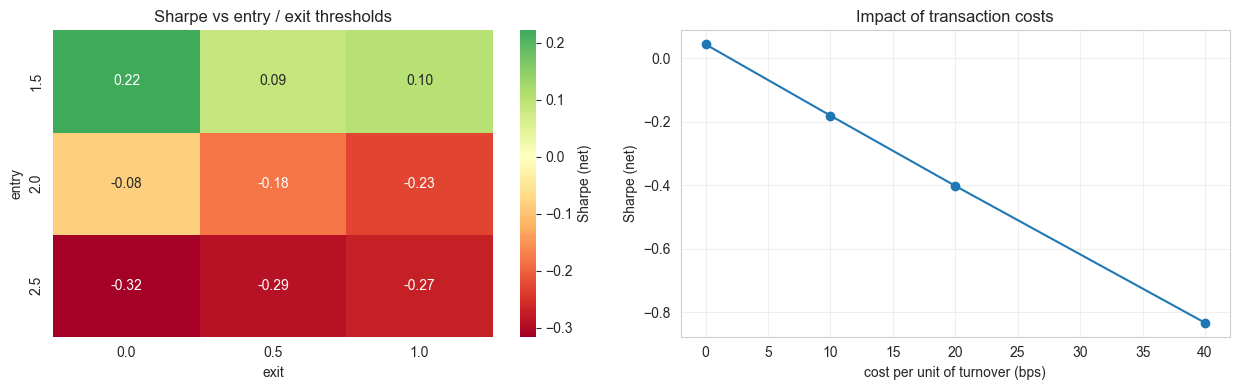

CPU times: user 5.93 s, sys: 56.7 ms, total: 5.99 s
Wall time: 5.96 s


,CAGR,Sharpe
fee_bps,,
0,+0.05%,0.04
10,-0.29%,-0.18
20,-0.63%,-0.40
40,-1.31%,-0.83


In [17]:
%%time
grid = []
for entry_ in [1.5, 2.0, 2.5]:
    for exit_ in [0.0, 0.5, 1.0]:
        r_ = run_trading(selections, entry_, exit_, P["stop"], P["fee"])
        grid.append(dict(entry=entry_, exit=exit_,
                         sharpe=np.sqrt(ANN) * r_.mean() / r_.std()))
grid = pd.DataFrame(grid).pivot(index="entry", columns="exit", values="sharpe")

fee_rows = []
for f_bps in [0, 10, 20, 40]:
    r_ = run_trading(selections, P["entry"], P["exit"], P["stop"], f_bps / 1e4)
    e_ = (1 + r_).cumprod()
    fee_rows.append(dict(fee_bps=f_bps,
                         CAGR=e_.iloc[-1] ** (ANN / len(r_)) - 1,
                         Sharpe=np.sqrt(ANN) * r_.mean() / r_.std()))
fee_tab = pd.DataFrame(fee_rows).set_index("fee_bps")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[0],
            cbar_kws={"label": "Sharpe (net)"})
axes[0].set_title("Sharpe vs entry / exit thresholds")
axes[1].plot(fee_tab.index, fee_tab["Sharpe"], "o-", color="#1f77b4")
axes[1].set_xlabel("cost per unit of turnover (bps)")
axes[1].set_ylabel("Sharpe (net)")
axes[1].set_title("Impact of transaction costs")
plt.tight_layout()
plt.show()
fee_show = fee_tab.copy().astype(object)
fee_show["CAGR"] = fee_tab["CAGR"].map("{:+.2%}".format)
fee_show["Sharpe"] = fee_tab["Sharpe"].map("{:.2f}".format)
fee_show

## 9. Conclusions

**Answer to the research question.** On the survivorship-bias-free S&P 500 universe,
1993–2018, with weekly rebalancing and realistic transaction costs, our cointegration
pairs-trading strategy did **not** deliver risk-adjusted returns superior to buy-and-hold:
the net Sharpe ratio is ≈ −0.2, against ≈ 0.5 for the index. The detailed findings are
more nuanced and, we believe, more interesting than a simple "it doesn't work":

1. **The strategy really is market-neutral.** Correlation and beta with the S&P 500 are
   ≈ 0.09 and ≈ 0.01: the equity curve is essentially independent of the market, running
   at ~1.5% annualized volatility (a tenth of the index) with a maximum drawdown of ~14%
   against ~56% for the index. In 2008, while the S&P 500 lost 41%, the strategy slipped
   only −4.6%. The *construction* delivers exactly what the theory promises.
2. **The edge existed — in the 1990s.** In 1993–2002 the strategy earned a gross Sharpe
   of ≈ 0.36 (≈ 0.14 even net of costs) on near-zero beta: the cointegration
   relationships selected in formation genuinely predicted out-of-sample mean reversion.
3. **And it has since disappeared.** In 2003–2018 even the *gross* Sharpe turns negative
   (≈ −0.2): spreads that diverge no longer reliably converge. This decay is precisely
   what Gatev et al. (2006) began documenting and Do & Faff (2010) confirmed — more
   efficient markets and more arbitrage capital chasing the same signal. Our independent
   implementation reproduces the literature's central result.
4. **Costs make a marginal strategy a losing one.** ≈ 20 bps per round trip subtracts
   roughly 0.2 from the Sharpe ratio (§8); survival requires execution below ~10 bps —
   an institutional, not retail, proposition — and even that would not fix the
   post-2003 signal decay.
5. **Practical verdict.** As a stand-alone investment the strategy loses to buy-and-hold
   in the modern sample. Its zero-beta, low-drawdown profile is genuinely attractive as
   *portfolio insurance*, but only for an investor who believes the spread-convergence
   edge can be revived (faster data, intraday execution, better pair selection).

**Known limitations and risks**

* *Cointegration breakdown*: mergers, spin-offs and regime changes can break the
  relationship; the 3-sigma stop and the 26-week maximum holding period are the defences.
* *Multiple testing*: scanning thousands of pairs finds some spurious "cointegration"
  by construction; the same-sector restriction, half-life filter and the fully
  out-of-sample design mitigate (but cannot eliminate) it.
* *Price index benchmark*: the S&P 500 series is a price index (no dividends); on the
  other side, the strategy's short legs would pay borrow fees and its long-short cash
  would earn interest — effects we deliberately leave out on both sides.
* *Execution*: weekly Friday closes ignore intraweek dynamics; costs are a flat estimate;
  short availability of every member is assumed.

**Possible extensions**: monthly-frequency comparison, Johansen test or distance method
as alternative selection criteria, volatility-scaled capital allocation across pairs,
rolling re-estimation of the hedge ratio (Kalman filter), Stoxx 600 universe.

**References.** Gatev, Goetzmann & Rouwenhorst (2006), *RFS* 19(3); Do & Faff (2010),
*FAJ* 66(4); Vidyamurthy (2004); Engle & Granger (1987); course slides *Pairs Trading
FMA* and the course notebook `pairs_trading.ipynb`.